In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor,
    AdaBoostRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

In [3]:
df = pd.read_csv(r"E:\ml projects\end-to-end-roundup-prediction\notebooks\roundup_data.csv")

In [4]:
df.head()

,txn_id,user_id,timestamp,txn_amount,category,transaction_hour,is_weekend,hour_sin,hour_cos,txn_count_today,...,income_tier,user_tenure_days,is_new_user,pressure_score,monthly_savings_so_far,user_savings_streak,days_since_last_txn,clean_number_tier,rounded_amount,roundup_amount
0,TXN_00000001,USR_0001,2024-09-02 09:39:46,464,food_delivery,9,0,0.7071,-0.7071,1,...,Low,229,0,0.0288,0,0,0,3,500,36
1,TXN_00000002,USR_0001,2024-09-02 13:53:43,460,ride_sharing,13,0,-0.2588,-0.9659,2,...,Low,229,0,0.8883,36,0,0,3,500,40
2,TXN_00000003,USR_0001,2024-09-02 18:12:46,130,ride_sharing,18,0,-1.0000,-0.0000,3,...,Low,229,0,0.9500,76,0,0,3,150,20
3,TXN_00000004,USR_0001,2024-09-14 08:48:51,360,shopping,8,1,0.8660,-0.5000,1,...,Low,241,0,0.0092,96,0,12,3,400,40
4,TXN_00000005,USR_0001,2024-09-14 13:16:36,692,ride_sharing,13,1,-0.2588,-0.9659,2,...,Low,241,0,0.7099,136,0,0,3,750,58


In [6]:
df = df.drop(columns=['user_id','txn_id','timestamp', 'rounded_amount'])

In [7]:
# Separate feature and target
X = df.drop(columns=['roundup_amount'])
y = df['roundup_amount']

In [8]:
X.head()

,txn_amount,category,transaction_hour,is_weekend,hour_sin,hour_cos,txn_count_today,daily_total_spent,remaining_daily_capacity,txn_count_prev_7d,avg_spend_last_7days,spending_velocity_ratio,income_tier,user_tenure_days,is_new_user,pressure_score,monthly_savings_so_far,user_savings_streak,days_since_last_txn,clean_number_tier
0,464,food_delivery,9,0,0.7071,-0.7071,1,0.0,600.0,0,450.0,1.0311,Low,229,0,0.0288,0,0,0,3
1,460,ride_sharing,13,0,-0.2588,-0.9659,2,464.0,136.0,0,450.0,1.0222,Low,229,0,0.8883,36,0,0,3
2,130,ride_sharing,18,0,-1.0000,-0.0000,3,924.0,-324.0,0,450.0,0.2889,Low,229,0,0.9500,76,0,0,3
3,360,shopping,8,1,0.8660,-0.5000,1,0.0,600.0,0,450.0,0.8000,Low,241,0,0.0092,96,0,12,3
4,692,ride_sharing,13,1,-0.2588,-0.9659,2,360.0,240.0,0,450.0,1.5378,Low,241,0,0.7099,136,0,0,3


In [9]:
y.head()

0    36
1    40
2    20
3    40
4    58
Name: roundup_amount, dtype: int64

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [11]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (19377, 20)
Test shape: (4845, 20)


In [13]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print("Numerical features: ", numerical_features)
print("\nCategorical features: ", categorical_features)

Numerical features:  ['txn_amount', 'transaction_hour', 'is_weekend', 'hour_sin', 'hour_cos', 'txn_count_today', 'daily_total_spent', 'remaining_daily_capacity', 'txn_count_prev_7d', 'avg_spend_last_7days', 'spending_velocity_ratio', 'user_tenure_days', 'is_new_user', 'pressure_score', 'monthly_savings_so_far', 'user_savings_streak', 'days_since_last_txn', 'clean_number_tier']

Categorical features:  ['category', 'income_tier']


In [14]:
# numerical features - preprocessing step
numerical_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# categorical features - preprocessing step
categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown='ignore'))
    ]
)

# preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

### Baseline Model

In [15]:
baseline_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]
)

In [16]:
# preprocess data and train the baseline model
baseline_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['txn_amount','category','transaction_hour',...,'user_savings_streak', 'days_since_last_txn','clean_number_tier']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automaticall

### Baseline model evaluation

In [17]:
train_baseline_pred = baseline_pipe.predict(X_train)
test_baseline_pred = baseline_pipe.predict(X_test)

In [18]:
train_baseline_rmse = root_mean_squared_error(y_train, train_baseline_pred)
train_baseline_mae = mean_absolute_error(y_train, train_baseline_pred)
train_baseline_r2 = r2_score(y_train, train_baseline_pred)

print("\n===TRAIN BASELINE METRICS (LinearRegression)===")
print(f"RMSE: {train_baseline_rmse:.3f}")
print(f"MAE: {train_baseline_mae:.3f}")
print(f"R²: {train_baseline_r2:.3f}")


===TRAIN BASELINE METRICS (LinearRegression)===
RMSE: 48.301
MAE: 28.256
R²: 0.512


In [19]:
test_baseline_rmse = root_mean_squared_error(y_test, test_baseline_pred)
test_baseline_mae = mean_absolute_error(y_test, test_baseline_pred)
test_baseline_r2 = r2_score(y_test, test_baseline_pred)

print("\n===TEST BASELINE METRICS (LinearRegression)===")
print(f"RMSE: {test_baseline_rmse:.3f}")
print(f"MAE: {test_baseline_mae:.3f}")
print(f"R²: {test_baseline_r2:.3f}")


===TEST BASELINE METRICS (LinearRegression)===
RMSE: 46.855
MAE: 28.023
R²: 0.482


### Model selection & Optimization

In [21]:
RANDOM_STATE = 42

In [22]:
# models to try
models = {
    "LinearRegression": LinearRegression(),

    "Ridge": Ridge(random_state=RANDOM_STATE),

    "Lasso": Lasso(random_state=RANDOM_STATE, max_iter=5000),

    "SVR": SVR(kernel='rbf', C=1.0, epsilon=0.1),

    "KNN": KNeighborsRegressor(n_neighbors=5),

    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "HistGB": HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.05,
        random_state=RANDOM_STATE
    ),

    "AdaBoost": AdaBoostRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=RANDOM_STATE
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

In [23]:
k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [24]:
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

In [25]:
rows = []

for name, model in models.items():
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", model)
        ]
    )
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    rows.append({
        "model": name,
        "cv_rmse": -scores["test_rmse"].mean(),
        "cv_mae": -scores["test_mae"].mean(),
        "cv_r2": scores["test_r2"].mean(),
    })

# sort based on the lowest rmse
cv_results = pd.DataFrame(rows).sort_values("cv_rmse")
print("====CV Model Comparison====")
print(cv_results)

====CV Model Comparison====
              model    cv_rmse     cv_mae     cv_r2
5      RandomForest   6.338227   2.124426  0.991404
8           XGBoost  16.369934   9.176423  0.942086
6            HistGB  18.046960  10.249846  0.930750
7          AdaBoost  39.459273  22.651306  0.673769
4               KNN  47.146262  25.449736  0.534499
1             Ridge  48.364983  28.302639  0.510240
0  LinearRegression  48.364999  28.304146  0.510239
2             Lasso  48.710816  27.607506  0.503279
3               SVR  52.017188  25.422437  0.433970


In [26]:
best_row = cv_results.sort_values("cv_rmse").iloc[0]

best_model_name = best_row["model"]
best_rmse = best_row["cv_rmse"]

print("Best model based on CV RMSE:")
print("Model:", best_model_name)
print("CV RMSE:", best_rmse)

Best model based on CV RMSE:
Model: RandomForest
CV RMSE: 6.338227412763068


### Best Model: RandomForestRegressor

---

### Hyperparameter tuning

In [27]:
model_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(random_state=RANDOM_STATE))
    ]
)

In [28]:
param_space = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None],
    'model__n_jobs': [-1]
}

In [29]:
rs = RandomizedSearchCV(
    estimator=model_pipe,
    param_distributions=param_space,
    n_iter=15,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2
)

In [30]:
# perform random search
rs.fit(X_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a b

In [31]:
print("===TUNED RandomForestRegressor CV====")
print("Best CV RMSE:", -rs.best_score_)
print("Best params:", rs.best_params_)

===TUNED RandomForestRegressor CV====
Best CV RMSE: 11.633909754680138
Best params: {'model__n_jobs': -1, 'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': None, 'model__max_depth': 20}


## Retraining with best params

In [32]:
best_model_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=20,
            min_samples_split=2,
            min_samples_leaf=2,
            max_features=None,
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ]
)

In [33]:
best_model_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['txn_amount','category','transaction_hour',...,'user_savings_streak', 'days_since_last_txn','clean_number_tier']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automaticall

## Final Evaluation

In [34]:
train_final_pred = best_model_pipe.predict(X_train)

train_final_rmse = root_mean_squared_error(y_train, train_final_pred)
train_final_mae = mean_absolute_error(y_train, train_final_pred)
train_final_r2 = r2_score(y_train, train_final_pred)

print("\n===Final Model (RandomForestRegressor) Train Performance===")
print(f"RMSE: {train_final_rmse:.3f}")
print(f"MAE: {train_final_mae:.3f}")
print(f"R²: {train_final_r2:.3f}")


===Final Model (RandomForestRegressor) Train Performance===
RMSE: 11.398
MAE: 7.283
R²: 0.973


In [35]:
test_final_pred = best_model_pipe.predict(X_test)

test_final_rmse = root_mean_squared_error(y_test, test_final_pred)
test_final_mae = mean_absolute_error(y_test, test_final_pred)
test_final_r2 = r2_score(y_test, test_final_pred)

print("\n===Final Model (RandomForestRegressor) Test Performance===")
print(f"RMSE: {test_final_rmse:.3f}")
print(f"MAE: {test_final_mae:.3f}")
print(f"R²: {test_final_r2:.3f}")


===Final Model (RandomForestRegressor) Test Performance===
RMSE: 12.541
MAE: 7.442
R²: 0.963


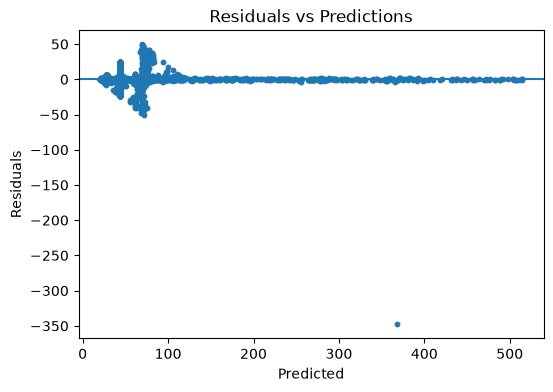

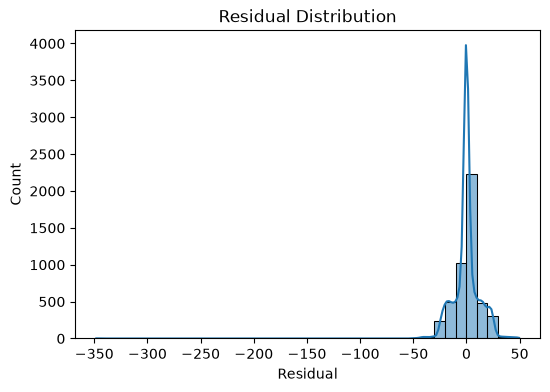

In [36]:
# residual plot
residuals = y_test - test_final_pred

plt.figure(figsize=(6, 4))
plt.scatter(test_final_pred, residuals, s=10)
plt.axhline(0)
plt.title("Residuals vs Predictions")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

## Building a predictive system

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24222 entries, 0 to 24221
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   txn_amount                24222 non-null  int64  
 1   category                  24222 non-null  str    
 2   transaction_hour          24222 non-null  int64  
 3   is_weekend                24222 non-null  int64  
 4   hour_sin                  24222 non-null  float64
 5   hour_cos                  24222 non-null  float64
 6   txn_count_today           24222 non-null  int64  
 7   daily_total_spent         24222 non-null  float64
 8   remaining_daily_capacity  24222 non-null  float64
 9   txn_count_prev_7d         24222 non-null  int64  
 10  avg_spend_last_7days      24222 non-null  float64
 11  spending_velocity_ratio   24222 non-null  float64
 12  income_tier               24222 non-null  str    
 13  user_tenure_days          24222 non-null  int64  
 14  is_new_user      

In [38]:
def predict_roundup(
    model,
    txn_amount: int,
    category: str,
    transaction_hour: int,
    is_weekend: int,
    txn_count_today: int,
    daily_total_spent: float,
    txn_count_prev_7d: int,
    avg_spend_last_7days: float,
    income_tier: str,
    user_tenure_days: int,
    is_new_user: int,
    monthly_savings_so_far: int,
    user_savings_streak: int,
    days_since_last_txn: int,
    clean_number_tier: int
) -> float:

    hour_sin = np.sin(2 * np.pi * transaction_hour / 24)
    hour_cos = np.cos(2 * np.pi * transaction_hour / 24)

    remaining_daily_capacity = max(0, avg_spend_last_7days - daily_total_spent)

    spending_velocity_ratio = (
        txn_count_today / txn_count_prev_7d
        if txn_count_prev_7d > 0 else 0
    )

    pressure_score = (
        daily_total_spent / avg_spend_last_7days
        if avg_spend_last_7days > 0 else 0
    )

    new_row = pd.DataFrame([{
        "txn_amount": txn_amount,
        "category": category,
        "transaction_hour": transaction_hour,
        "is_weekend": is_weekend,
        "hour_sin": hour_sin,
        "hour_cos": hour_cos,
        "txn_count_today": txn_count_today,
        "daily_total_spent": daily_total_spent,
        "remaining_daily_capacity": remaining_daily_capacity,
        "txn_count_prev_7d": txn_count_prev_7d,
        "avg_spend_last_7days": avg_spend_last_7days,
        "spending_velocity_ratio": spending_velocity_ratio,
        "income_tier": income_tier,
        "user_tenure_days": user_tenure_days,
        "is_new_user": is_new_user,
        "pressure_score": pressure_score,
        "monthly_savings_so_far": monthly_savings_so_far,
        "user_savings_streak": user_savings_streak,
        "days_since_last_txn": days_since_last_txn,
        "clean_number_tier": clean_number_tier
    }])

    return float(model.predict(new_row)[0])

#### Test Case 1: Low-income user, small transaction, early in the day, low daily spend

In [39]:
pred1 = predict_roundup(
    best_model_pipe,
    txn_amount=230,
    category="food_delivery",
    transaction_hour=8,
    is_weekend=0,
    txn_count_today=1,
    daily_total_spent=0.0,
    txn_count_prev_7d=3,
    avg_spend_last_7days=420.0,
    income_tier="Low",
    user_tenure_days=180,
    is_new_user=0,
    monthly_savings_so_far=150,
    user_savings_streak=0,
    days_since_last_txn=2,
    clean_number_tier=3
)
print("Test 1 - Low income, small txn, fresh day:", "Predicted Roundup:", pred1)

Test 1 - Low income, small txn, fresh day: Predicted Roundup: 20.0


#### Test Case 2: High-income user, large transaction, evening, high daily total already spent

In [40]:
pred2 = predict_roundup(
    best_model_pipe,
    txn_amount=2150,
    category="ride_sharing",
    transaction_hour=19,
    is_weekend=1,
    txn_count_today=3,
    daily_total_spent=3850.0,
    txn_count_prev_7d=12,
    avg_spend_last_7days=1680.0,
    income_tier="High",
    user_tenure_days=290,
    is_new_user=0,
    monthly_savings_so_far=420,
    user_savings_streak=5,
    days_since_last_txn=0,
    clean_number_tier=1
)
print("Test 2 - High income, large txn, high daily spent:", "Predicted Roundup:", pred2)

Test 2 - High income, large txn, high daily spent: Predicted Roundup: 351.26190079365085


#### Test Case 3: New user (is_new_user=1), medium txn, shopping category

In [41]:
pred3 = predict_roundup(
    best_model_pipe,
    txn_amount=680,
    category="shopping",
    transaction_hour=14,
    is_weekend=0,
    txn_count_today=2,
    daily_total_spent=450.0,
    txn_count_prev_7d=0,
    avg_spend_last_7days=0.0,
    income_tier="Medium",
    user_tenure_days=12,
    is_new_user=1,
    monthly_savings_so_far=0,
    user_savings_streak=0,
    days_since_last_txn=0,
    clean_number_tier=2
)
print("Test 3 - New user, shopping:", "Predicted Roundup:", pred3)

Test 3 - New user, shopping: Predicted Roundup: 21.871331455691216


#### Test Case 4: Weekend evening food delivery, moderate daily spend, good savings streak

In [42]:
pred4 = predict_roundup(
    best_model_pipe,
    txn_amount=1240,
    category="food_delivery",
    transaction_hour=20,
    is_weekend=1,
    txn_count_today=4,
    daily_total_spent=1850.0,
    txn_count_prev_7d=15,
    avg_spend_last_7days=920.0,
    income_tier="Low",
    user_tenure_days=245,
    is_new_user=0,
    monthly_savings_so_far=680,
    user_savings_streak=8,
    days_since_last_txn=1,
    clean_number_tier=3
)
print("Test 4 - Weekend food delivery, savings streak:", "Predicted Roundup:", pred4)

Test 4 - Weekend food delivery, savings streak: Predicted Roundup: 44.22206872537013


#### Test Case 5: Ecommerce, high velocity, near daily capacity, High income

In [43]:
pred5 = predict_roundup(
    best_model_pipe,
    txn_amount=2890,
    category="ecommerce",
    transaction_hour=16,
    is_weekend=0,
    txn_count_today=5,
    daily_total_spent=3720.0,
    txn_count_prev_7d=18,
    avg_spend_last_7days=1950.0,
    income_tier="High",
    user_tenure_days=310,
    is_new_user=0,
    monthly_savings_so_far=1250,
    user_savings_streak=12,
    days_since_last_txn=3,
    clean_number_tier=1
)
print("Test 5 - High velocity ecommerce, near capacity:", "Predicted Roundup:", pred5)

Test 5 - High velocity ecommerce, near capacity: Predicted Roundup: 109.08114285714288
